In [12]:
import numpy as np
import pandas as pd

# Generate 1000 random points in the range -1 to 1
points = np.random.randint(-10, 10, (10, 3))

# Display the original points
print("Original Points:")
display(pd.DataFrame(points, columns=['X', 'Y', 'Z']).T.style.hide(axis='columns'))

Original Points:


X,-10,-8,-1,-1,0,4,-2,-1,9,-2
Y,-7,-3,2,7,-7,2,-7,-6,-1,-5
Z,-2,-8,-4,7,-7,-10,-8,0,8,4


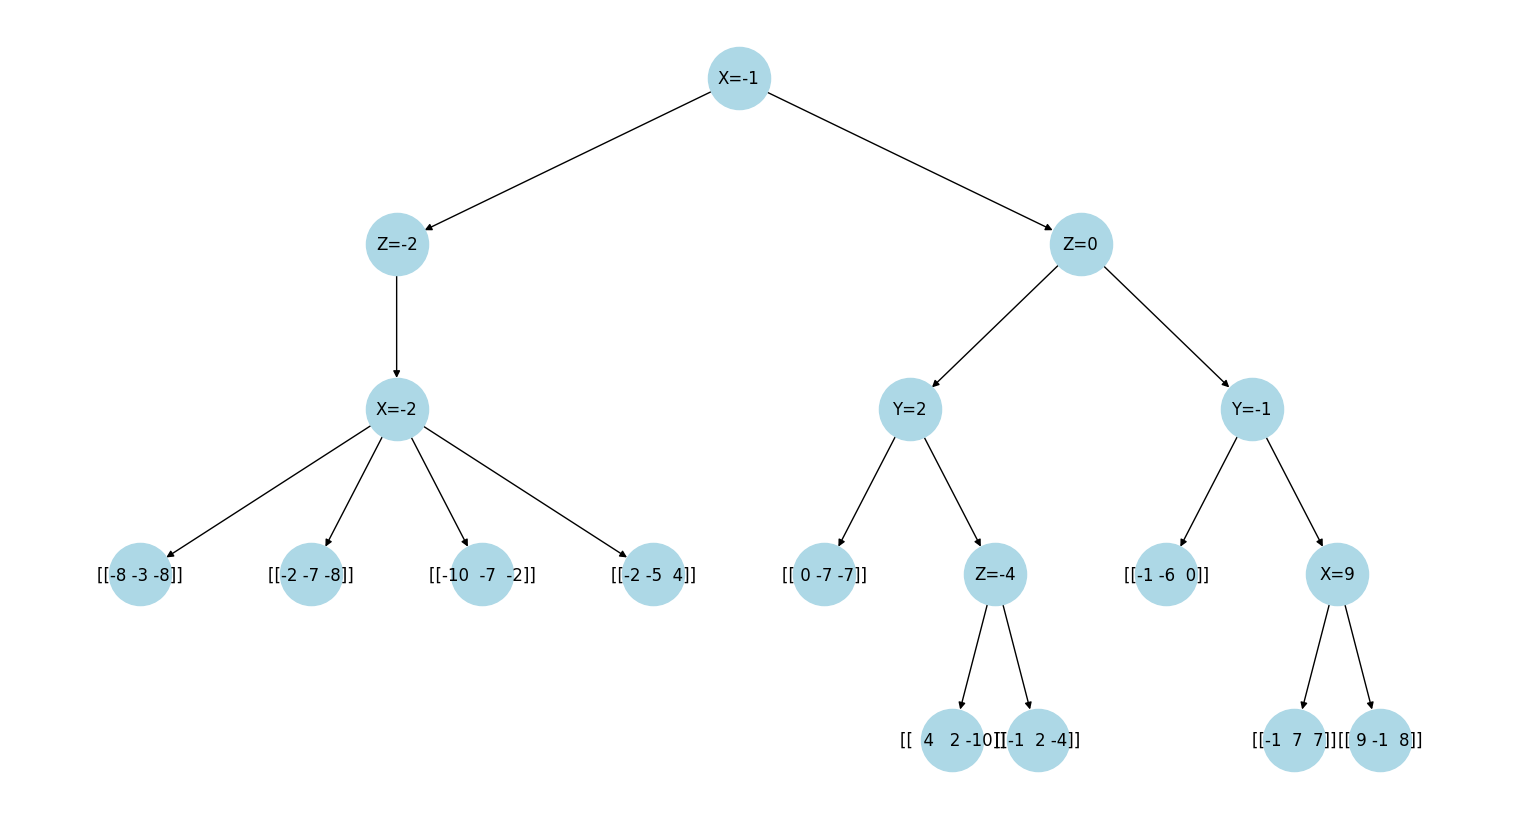

In [ ]:
from copy import deepcopy
import networkx as nx
from scipy.spatial import KDTree
import matplotlib.pyplot as plt

# Build a kd-tree from the points
kd_tree = KDTree(points, leafsize=1)

def hierarchy_pos(G, root=None, width=1., vert_gap = 0.2, vert_loc = 0, xcenter = 0.5):

    '''
    From Joel's answer at https://stackoverflow.com/a/29597209/2966723.
    Licensed under Creative Commons Attribution-Share Alike

    If the graph is a tree this will return the positions to plot this in a
    hierarchical layout.

    G: the graph (must be a tree)

    root: the root node of current branch
    - if the tree is directed and this is not given,
      the root will be found and used
    - if the tree is directed and this is given, then
      the positions will be just for the descendants of this node.
    - if the tree is undirected and not given,
      then a random choice will be used.

    width: horizontal space allocated for this branch - avoids overlap with other branches

    vert_gap: gap between levels of hierarchy

    vert_loc: vertical location of root

    xcenter: horizontal location of root
    '''
    if not nx.is_tree(G):
        raise TypeError('cannot use hierarchy_pos on a graph that is not a tree')

    if root is None:
        if isinstance(G, nx.DiGraph):
            root = next(iter(nx.topological_sort(G)))  #allows back compatibility with nx version 1.11
        else:
            root = random.choice(list(G.nodes))

    def _hierarchy_pos(G, root, width=1., vert_gap = 0.2, vert_loc = 0, xcenter = 0.5, pos = None, parent = None):
        '''
        see hierarchy_pos docstring for most arguments

        pos: a dict saying where all nodes go if they have been assigned
        parent: parent of this branch. - only affects it if non-directed

        '''

        if pos is None:
            pos = {root:(xcenter,vert_loc)}
        else:
            pos[root] = (xcenter, vert_loc)
        children = list(G.neighbors(root))
        if not isinstance(G, nx.DiGraph) and parent is not None:
            children.remove(parent)
        if len(children)!=0:
            dx = width/len(children)
            nextx = xcenter - width/2 - dx/2
            for child in children:
                nextx += dx
                pos = _hierarchy_pos(G,child, width = dx, vert_gap = vert_gap,
                                    vert_loc = vert_loc-vert_gap, xcenter=nextx,
                                    pos=pos, parent = root)
        return pos


    return _hierarchy_pos(G, root, width, vert_gap, vert_loc, xcenter)

def plot_kd_tree(tree: KDTree):
	G = nx.DiGraph()

	def add_to_graph(node: KDTree.node):
		if node is None:
			return

		if isinstance(node, KDTree.leafnode):
			graph_node = str(points[node.idx])
			G.add_node(graph_node)
			return graph_node

		assert isinstance(node, KDTree.innernode)
		graph_node = len(G.nodes)
		G.add_node(graph_node, label='XYZ'[node.split_dim] + f'={int(node.split)}')
		G.add_edge(graph_node, add_to_graph(node.less))
		G.add_edge(graph_node, add_to_graph(node.greater))
		return graph_node

	pos = hierarchy_pos(G, root=add_to_graph(tree.tree))
	plt.figure(figsize=(15, 8))  # Adjust the figure size to take all available width
	nx.draw(G, pos=pos, with_labels=True, arrows=True, node_size=2000, node_color='lightblue')
	plt.show()

# Visualize the kd-tree as a binary tree
plot_kd_tree(kd_tree)

Eytzinger Layout Points:


X,3,0,-5,-3,-8,2,4,3,5,6
Y,-7,1,1,-10,5,2,5,3,-5,5
Z,5,-8,-4,-7,0,-1,-3,4,-9,-10


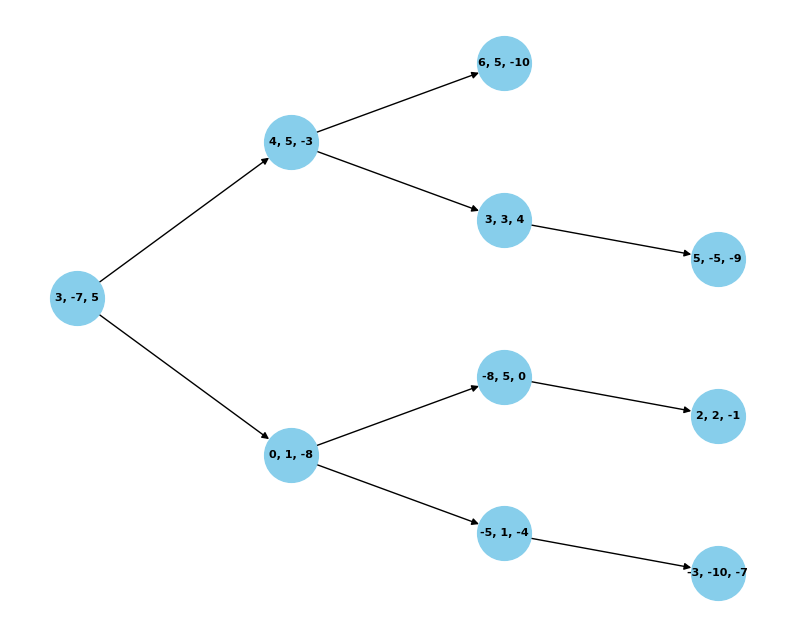

In [7]:

def eytzinger_layout(points, depth=0):
	if not points:
		return []

	# Sort points based on the current axis
	axis = depth % 3
	points = sorted(points, key=lambda x: x[axis])

	mid = len(points) // 2
	return [points[mid]] + eytzinger_layout(points[:mid], depth + 1) + eytzinger_layout(points[mid + 1:], depth + 1)

sorted_points = eytzinger_layout(points.tolist())

print("Eytzinger Layout Points:")
display(pd.DataFrame(sorted_points, columns=['X', 'Y', 'Z']).T.style.hide(axis='columns'))

# Convert sorted_points to numpy array for consistency
sorted_points_array = np.array(sorted_points)

# Reuse the plot_kd_tree function with the sorted points
plot_kd_tree(sorted_points_array)
